# <center>神经微分方程：二分类问题</center>

## 1. 问题描述

给定二维数据点 $\{ X = (X_0, X_1) \}_{x\in\Omega}$ 及其所对应的标签 $y \in \{0, 1\}$，训练一个神经微分方程实现二分类任务。在此，将分别考虑

- Half-Moons 数据集
- Concentric Circles 数据集

#### 1-1. 建立神经微分方程模型

首先将数据点作为初始值，然后通过神经微分方程进行前向演化

$$
\mathbf{x} (0) = X; \ \
\frac{d \mathbf{x} (t)}{dt} = f_{\textnormal{NN}}( \mathbf{x} (t), t; \theta )
\ \ \
\textnormal{for}
\ \ \
0 < t\leq 1,
$$
其中方程的右端项用神经网络进行参数化，且此时可训练参数 $\theta$ 与时间变量 $t$ 无关。

#### 1-2. 损失函数及其优化问题

针对单个数据点 $\mathbf{x} (0) = X$，在得到 $t=1$ 时刻的演化数据 $\mathbf{x} (1)$ 后，通过 softmax 函数将结果转化为的分类概率
$$
\sigma( \mathbf{x} (1) ) = \left( \frac{ e^{\mathbf{x}_1(1)} }{ e^{\mathbf{x}_1(1)} + e^{\mathbf{x}_2(1)} }，  \frac{ e^{\mathbf{x}_2(1)} }{ e^{\mathbf{x}_1(1)} + e^{\mathbf{x}_2(1)} } \right) 
$$
接下来便可在交叉熵（cross entropy）的度量下与真实分类 $y\in\{0, 1\}$ 进行比较
$$
\varphi( \mathbf{x} (1) ) = -  \left[ y \log^{\sigma_0( \mathbf{x} (1) )} + (1-y) \log^{\sigma_1( \mathbf{x} (1) )} \right] := \textnormal{CrossEntropyLoss}( \mathbf{x} (1), y).
$$
因此，神经网络可训练参数所对应的优化问题为
\begin{equation*}
	\begin{array}{cl}
		\displaystyle  \min_\theta & \displaystyle \mathbb{E}_{X\in\Omega} \big[ \varphi( \mathbf{x} (1) ) \big] \\
		\textnormal{s.t.} & \displaystyle  \mathbf{x} (0) = X; \ \
\frac{d \mathbf{x} (t)}{dt} = f_{\textnormal{NN}}( \mathbf{x} (t), t; \theta )\ \ \
\textnormal{for}
\ \ \
0 < t\leq 1.
	\end{array}
\end{equation*}

#### 1-3. 基于伴随方程方法求解

通过变分原理（Calculus of Variations）来求解上述最优控制问题，特别的，torchdiffeq 库中的 odeint 函数巧妙地封装了整个过程。

## 2. 编程求解（Half-Moons 数据集）

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, random_split, DataLoader
from IPython.display import HTML # for animation

import matplotlib.pyplot as plt

# generate sample points and their labels
from Dataset.Generate_Dataset import MoonsDataset
import Dataset.Visualize_Dataset_Binary_Classification as Visualization

# construct neural ODE (require torchdiffeq)
try:
    import torchdiffeq
except ModuleNotFoundError:
    !pip install --quiet torchdiffeq
    import torchdiffeq
from Models.Neural_ODE import NODE
from Models.Neural_ODE import NODE_Trainer

# use PyTorch Lightning to simplify coding
try:
    import pytorch_lightning as pl
except ModuleNotFoundError:
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl   

# for reproducibility
pl.seed_everything(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import warnings
warnings.filterwarnings("ignore")  # ignore warnings for concise

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Seed set to 42


Device: cpu


### 2-1. 创建训练与测试数据集

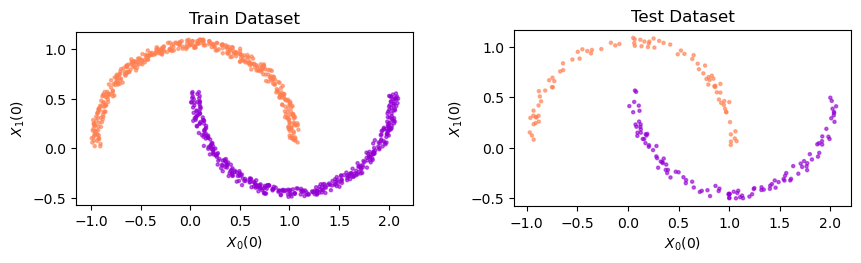

In [2]:
datasize_train = 800
batchsize_train = 200
datasize_test = 200

# create training and testing datasets   
dataset_full = MoonsDataset(datasize_train + datasize_test, noise_std=1e-1)
dataset_train, dataset_test = random_split(dataset_full, [datasize_train, datasize_test])

# visualize training and testing datasets
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3)) 
Visualization.plot_binary_classification_dataset(*dataset_train[:], title='Train Dataset', x_label='$X_0(0)$', y_label='$X_1(0)$', ax=ax0)  
Visualization.plot_binary_classification_dataset(*dataset_test[:], title='Test Dataset', x_label='$X_0(0)$', y_label='$X_1(0)$', ax=ax1) 
plt.subplots_adjust(wspace=0.3) 

# define dataloader
dataloader_train = DataLoader(dataset_train, batch_size=batchsize_train, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=len(dataset_test), shuffle=False)

In [3]:
# print datasets if necessary
Visualization.print_train_test_dataloader(dataloader_train, dataloader_test) 

╒════════════════╤═══════════════════════════════════════════╤═══════════════════════════════════════════╕
│                │ Train DataLoader                          │ Test DataLoader                           │
╞════════════════╪═══════════════════════════════════════════╪═══════════════════════════════════════════╡
│ fullbatch_size │ 800                                       │ 200                                       │
├────────────────┼───────────────────────────────────────────┼───────────────────────────────────────────┤
│ minibatch_size │ 200                                       │ 200                                       │
├────────────────┼───────────────────────────────────────────┼───────────────────────────────────────────┤
│ data_shape     │ torch.Size([200, 2]) (type=torch.float32) │ torch.Size([200, 2]) (type=torch.float32) │
├────────────────┼───────────────────────────────────────────┼───────────────────────────────────────────┤
│ data_sample    │ tensor([[ 1.9686, 

### 2-2. 建立并训练神经微分方程

In [4]:
NODE_RHS = nn.Sequential(
    nn.Linear(2, 64),
    nn.Tanh(),
    nn.Linear(64, 2))
model = NODE(NODE_RHS, adjoint=True)

t_span = torch.linspace(0, 1, 2)
model_trainer = NODE_Trainer(model, t_span)
trainer = pl.Trainer(
    max_epochs = 200,
    accelerator = "gpu" if torch.cuda.is_available() else "cpu",
    enable_progress_bar = False, logger = False, enable_checkpointing=False, # for simplicity
)
trainer.fit(model_trainer, dataloader_train)
trainer.test(model_trainer, dataloader_test, verbose=True)

print('test loss = {:.4e}'.format(model_trainer.test_loss[-1]))

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type | Params | Mode 
---------------------------------------
0 | model | NODE | 322    | train
---------------------------------------
322       Trainable params
0         Non-trainable params
322       Total params
0.001     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=200` reached.


test loss = 2.1240e-04


### 2-3. 展示数据在神经微分方程中的流动

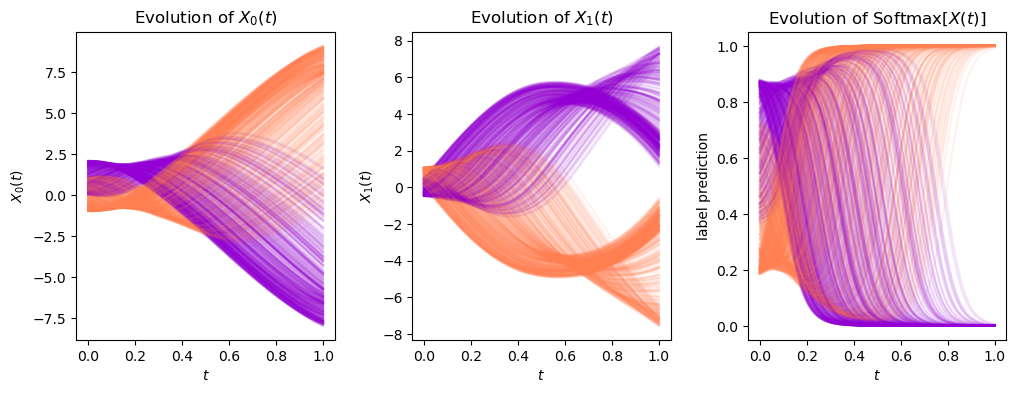

In [5]:
# generate trajectories through the trained model
@torch.no_grad()
def run_inference(trainer, data_loader, time_span):
    trainer.to(device)
    trajectories = []
    classes = []
    label_trajectories = []
    time_span = torch.from_numpy(time_span).to(device)
    for data, target in data_loader:
        data = data.to(device)        
        traj, label = trainer.inference(data, time_span)                  
        trajectories.append(traj.cpu().numpy())
        label_trajectories.append(label.cpu().numpy())
        classes.extend(target.numpy())        
    trajectories = np.concatenate(trajectories, 1)
    label_trajectories = np.concatenate(label_trajectories, 1)
    return trajectories, label_trajectories, classes

time_span = np.linspace(0.0, 1.0, 100)
trajectories, label_trajectories, classes = run_inference(model_trainer, dataloader_train, time_span)

# plot trajectories of data points and their labels
colors = ['coral', 'darkviolet']
class_colors = [colors[ci] for ci in classes]

# trajectories
Visualization.plot_trajectories(time_span, trajectories, label_trajectories, class_colors)

In [6]:
# animation
anim = Visualization.plot_trajectories_animation(time_span, trajectories, colors, classes, lim=8.0)
HTML(anim.to_html5_video())

神经微分方程通过对数据点进行位置变换，较好的简化了原本较难的分类任务。然而，这种坐标变换本质上是同胚映射，无法改变输入空间的拓扑结构。

## 3. 编程求解（Concentric-Circles 数据集）

In [7]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, random_split, DataLoader
from IPython.display import HTML # for animation

import matplotlib.pyplot as plt

# generate sample points and their labels
from Dataset.Generate_Dataset import ConcentricCirclesDataset
import Dataset.Visualize_Dataset_Binary_Classification as Visualization

# construct neural ODE (require torchdiffeq)
try:
    import torchdiffeq
except ModuleNotFoundError:
    !pip install --quiet torchdiffeq
    import torchdiffeq
from Models.Neural_ODE import NODE
from Models.Neural_ODE import NODE_Trainer

# use PyTorch Lightning to simplify coding
try:
    import pytorch_lightning as pl
except ModuleNotFoundError:
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl   

# for reproducibility
pl.seed_everything(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import warnings
warnings.filterwarnings("ignore")  # ignore warnings for concise

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Seed set to 42


Device: cpu


### 3-1. 创建训练与测试数据集

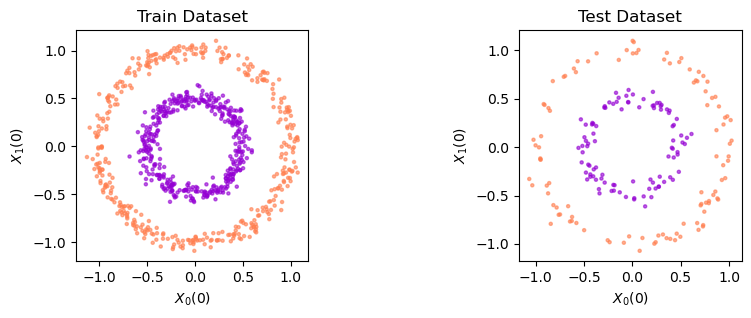

In [8]:
datasize_train = 800
batchsize_train = 800
datasize_test = 200

# create training and testing datasets   z
dataset_full = ConcentricCirclesDataset(datasize_train + datasize_test, noise_std=5e-2)
dataset_train, dataset_test = random_split(dataset_full, [datasize_train, datasize_test])

# visualize training and testing datasets
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3)) 
Visualization.plot_binary_classification_dataset(*dataset_train[:], title='Train Dataset', x_label='$X_0(0)$', y_label='$X_1(0)$', ax=ax0)  
Visualization.plot_binary_classification_dataset(*dataset_test[:], title='Test Dataset', x_label='$X_0(0)$', y_label='$X_1(0)$', ax=ax1) 
plt.subplots_adjust(wspace=0.3) 

# define dataloader
dataloader_train = DataLoader(dataset_train, batch_size=batchsize_train, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=len(dataset_test), shuffle=False)

In [9]:
# print datasets if necessary
Visualization.print_train_test_dataloader(dataloader_train, dataloader_test) 

╒════════════════╤═══════════════════════════════════════════╤═══════════════════════════════════════════╕
│                │ Train DataLoader                          │ Test DataLoader                           │
╞════════════════╪═══════════════════════════════════════════╪═══════════════════════════════════════════╡
│ fullbatch_size │ 800                                       │ 200                                       │
├────────────────┼───────────────────────────────────────────┼───────────────────────────────────────────┤
│ minibatch_size │ 800                                       │ 200                                       │
├────────────────┼───────────────────────────────────────────┼───────────────────────────────────────────┤
│ data_shape     │ torch.Size([800, 2]) (type=torch.float32) │ torch.Size([200, 2]) (type=torch.float32) │
├────────────────┼───────────────────────────────────────────┼───────────────────────────────────────────┤
│ data_sample    │ tensor([[0.1437, 0

### 3-2. 建立并训练神经微分方程

In [10]:
NODE_RHS = nn.Sequential(
    nn.Linear(2, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 2))
model = NODE(NODE_RHS, adjoint=True)

t_span = torch.linspace(0, 1, 2)
model_trainer = NODE_Trainer(model, t_span)
trainer = pl.Trainer(
    max_epochs = 300,
    accelerator = "gpu" if torch.cuda.is_available() else "cpu",
    enable_progress_bar = False, logger = False, enable_checkpointing=False, # for simplicity
)
trainer.fit(model_trainer, dataloader_train)
trainer.test(model_trainer, dataloader_test, verbose=True)

print('test loss = {:.4e}'.format(model_trainer.test_loss[-1]))

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type | Params | Mode 
---------------------------------------
0 | model | NODE | 4.5 K  | train
---------------------------------------
4.5 K     Trainable params
0         Non-trainable params
4.5 K     Total params
0.018     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=300` reached.


test loss = 2.1488e-02


### 3-3. 展示数据在神经微分方程中的流动

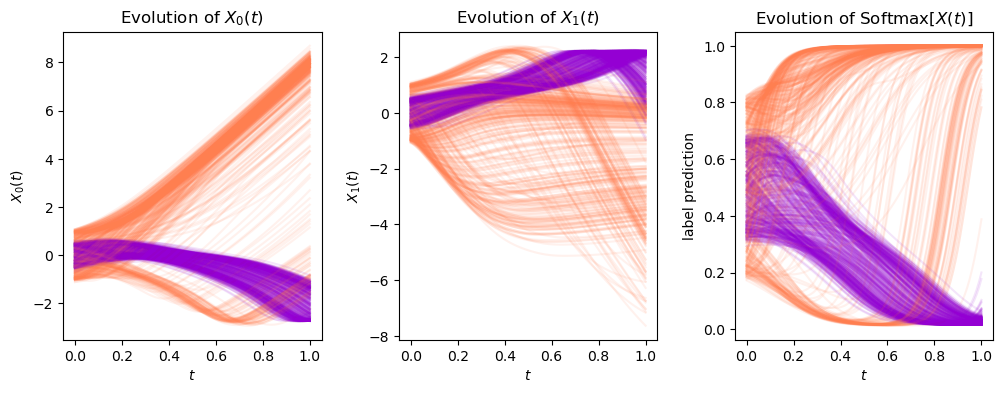

In [11]:
# generate trajectories through the trained model
@torch.no_grad()
def run_inference(trainer, data_loader, time_span):
    trainer.to(device)
    trajectories = []
    classes = []
    label_trajectories = []
    time_span = torch.from_numpy(time_span).to(device)
    for data, target in data_loader:
        data = data.to(device)        
        traj, label = trainer.inference(data, time_span)                  
        trajectories.append(traj.cpu().numpy())
        label_trajectories.append(label.cpu().numpy())
        classes.extend(target.numpy())        
    trajectories = np.concatenate(trajectories, 1)
    label_trajectories = np.concatenate(label_trajectories, 1)
    return trajectories, label_trajectories, classes

time_span = np.linspace(0.0, 1.0, 100)
trajectories, label_trajectories, classes = run_inference(model_trainer, dataloader_train, time_span)

# plot trajectories of data points and their labels
colors = ['coral', 'darkviolet']
class_colors = [colors[ci] for ci in classes]

# trajectories
Visualization.plot_trajectories(time_span, trajectories, label_trajectories, class_colors)

In [12]:
# animation
anim = Visualization.plot_trajectories_animation(time_span, trajectories, colors, classes, lim=8.0)
HTML(anim.to_html5_video())

神经微分方程的测试误差咋看起来也可以接受，似乎与其无法改变输入空间拓扑结构的理论相违背。但动画清晰地表明，神经微分方程过度拉伸了部分空间来作弊，通过扩大数据点之间的间距使得内圈的数据点能够流出该区域。尽管在当前数据集上实现了较高精度，但牺牲了泛化能力，并增加了训练和推理时间。

## 4. 课后练习（Talk is cheap. Show me the code.）

如何赋予神经微分方程改变拓扑结构的能力？请构建有效算法并进行理论分析，同时以 Concentric-Circles 数据集为例编程验证（提示：升维）。